In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sin
from random import uniform

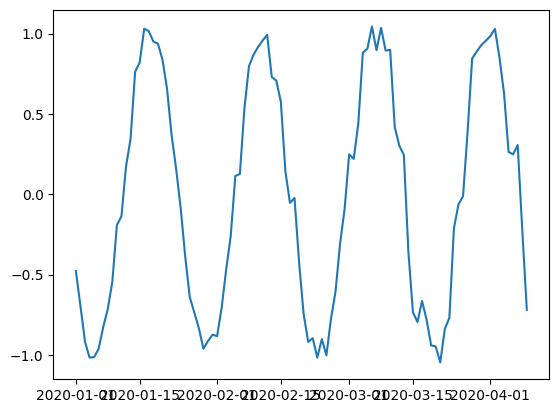

In [161]:
base_freq = 8
r_noise = 0.1
r_freq = 0.1
delta = 10
# create pandas datafrme with datetime columns and a sin column
df = pd.DataFrame({
    'date': pd.date_range('2020-01-01', periods=100, freq='D'),
    'value': [sin((base_freq+uniform(-r_freq,r_freq))*x+delta)+uniform(-r_noise, r_noise) for x in np.linspace(0, np.pi, 100)]
})  
plt.plot(df['date'], df['value'])
plt.show()


In [162]:
#dir = 'time_series_classification_easy'
dir = 'time_series_classification_hard'


params = {
    0:{
        'base_freq': 4,
        'r_noise': 0.1,
        'r_freq': 0.1,
    },
    1:{
        'base_freq': 6,
        'r_noise': 0.1,
        'r_freq': 0.1,
    }
}

for dir in ['time_series_classification_easy', 'time_series_classification_hard']:
    for p in params:
        base_freq = params[p]['base_freq']
        r_noise = params[p]['r_noise']
        r_freq = params[p]['r_freq']

        for i in range(100):
            d = uniform(-1, 1) if dir == 'time_series_classification_easy' else i
            df = pd.DataFrame({
            'date': pd.date_range('2020-01-01', periods=100, freq='D'),
            'value': [sin((base_freq+uniform(-r_freq,r_freq))*x+d)+uniform(-r_noise, r_noise) for x in np.linspace(0, np.pi, 100)]
            })
            #save the data
            df.to_csv(f'../../datasets/{dir}/class_{p}_{i}.csv', index=False)  


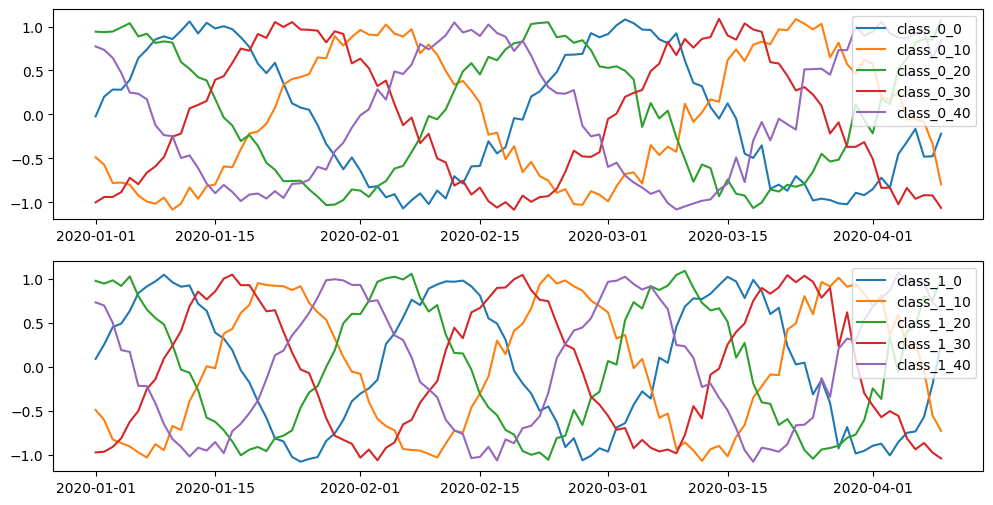

In [168]:
#dir = 'time_series_classification_easy'
dir = 'time_series_classification_hard'
import os   
dfs = []
for file in os.listdir(f'../../datasets/{dir}/'):
    if file.endswith('.csv'):
        df = pd.read_csv(f'../../datasets/{dir}/{file}')
        df['date'] = pd.to_datetime(df['date'])
        df['id'] = file.split('.')[0]       
        dfs.append(df)
df = pd.concat(dfs)


to_display_0 = ['class_0_0','class_0_10','class_0_20','class_0_30','class_0_40']
to_display_1 = ['class_1_0','class_1_10','class_1_20','class_1_30','class_1_40']
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
for i in to_display_0:
    d = df.loc[df['id']==i]
    d = d.sort_values('date')
    plt.plot(d['date'], d['value'], label=i)
plt.legend(loc='upper right')
plt.subplot(2,1,2)
for i in to_display_1:
    d = df.loc[df['id']==i]
    d = d.sort_values('date')
    plt.plot(d['date'], d['value'], label=i)
plt.legend(loc='upper right')
plt.show()